#Syntax of Conv2D Layer

In [1]:
from tensorflow.keras.layers import Conv2D

# Define example values for filters and kernel_size
filters = 32
kernel_size = (3, 3)

layer = Conv2D(filters, kernel_size, strides=(1,1), padding="valid", activation=None, use_bias=True, kernel_initializer="glorot_uniform")
print(layer)

<Conv2D name=conv2d, built=False>


#End - to - End CNN Model

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9618 - loss: 0.1291 - val_accuracy: 0.9872 - val_loss: 0.0402
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9863 - loss: 0.0434 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.9909 - val_loss: 0.0288
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9932 - loss: 0.0210 - val_accuracy: 0.9908 - val_loss: 0.0318
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.9900 - val_loss: 0.0323
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9900 - loss: 0.0323
Test accuracy: 0.9900
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Data Understanding and Visualisation

Visualise one random image per class

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/6th sem AI/Data/Copy of FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/FruitinAmazon'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset unzipped to: {extract_path}")

Dataset unzipped to: /content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/FruitinAmazon


Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


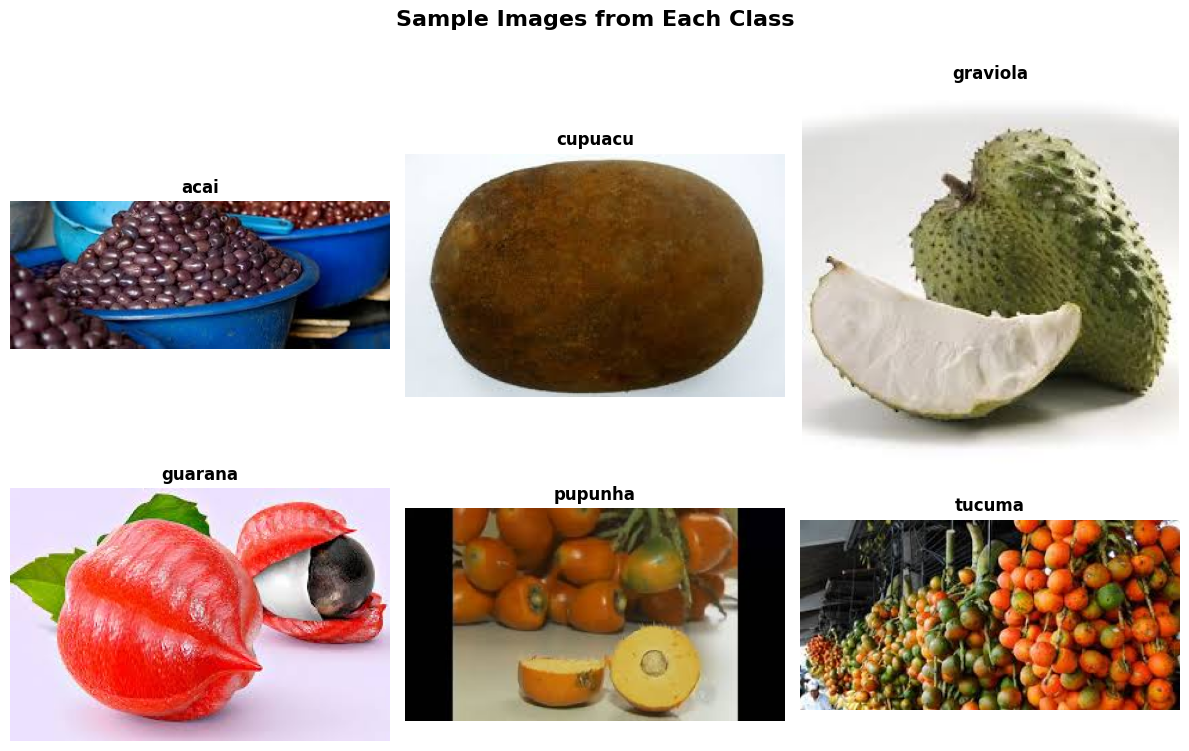


Observation: The dataset contains 6 Amazon fruit classes with varying
colours, textures, sizes and backgrounds - typical real-world challenges.


In [4]:

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Assuming TRAIN_DIR needs to be defined for a dataset.
# This is a placeholder; you'll need to set the correct path to your training data.
# For example, if your data is in a folder named 'train' in the current directory:
TRAIN_DIR = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/FruitinAmazon/FruitinAmazon/train'

# Get all class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f"Classes found ({num_classes}):", class_dirs)

# Select one random image from each class
sample_images = []
sample_labels = []
for cls in class_dirs:
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_files = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    chosen    = random.choice(img_files)
    sample_images.append(os.path.join(cls_path, chosen))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2          # number of columns
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for idx, (img_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide any unused axes
for j in range(len(sample_images), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nObservation: The dataset contains 6 Amazon fruit classes with varying")
print("colours, textures, sizes and backgrounds - typical real-world challenges.")

Check for corrupted images

In [5]:
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        if not os.path.isfile(img_path):
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()          # verify integrity without decoding
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")

No Corrupted Images Found.


Loading and Preprocessing Image Data

In [6]:
import tensorflow as tf

# Define image preprocessing parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
# Assuming a similar directory structure for test data, adjust if needed
TEST_DIR = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/FruitinAmazon/FruitinAmazon/test'

# Rescaling layer – normalise pixel values from [0, 255] → [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)
# Capture class names from the training dataset before mapping
CLASS_NAMES = train_ds_raw.class_names
num_classes = len(CLASS_NAMES)
print("Class names:", CLASS_NAMES)

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────────
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))


# Performance optimisation
AUTOTUNE  = tf.data.AUTOTUNE
train_ds  = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds    = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds   = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


Implement the CNN Architecture

In [7]:
def build_cnn(input_shape, num_classes):
    """
    CNN architecture as specified in the worksheet:
    Conv(32, 3×3, same) → ReLU → MaxPool(2×2)
    Conv(32, 3×3, same) → ReLU → MaxPool(2×2)
    Flatten → Dense(128) → Dense(64) → Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        # ── Convolutional Block 1 ──────────────────────────
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding='same',
            strides=(1, 1),
            activation='relu',
            input_shape=input_shape,
            name='conv1'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool1'
        ),

        # ── Convolutional Block 2 ──────────────────────────
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding='same',
            strides=(1, 1),
            activation='relu',
            name='conv2'
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=2,
            name='pool2'
        ),

        # ── Fully Connected Network ────────────────────────
        layers.Flatten(name='flatten'),

        # Hidden Layer 1 (128 neurons)
        layers.Dense(128, activation='relu', name='dense_128'),

        # Hidden Layer 2 (64 neurons)
        layers.Dense(64, activation='relu', name='dense_64'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='Fruit_CNN')

    return model

In [8]:
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
model = build_cnn(INPUT_SHAPE, num_classes)
model.summary()

Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Compile the Model

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [10]:

# 1. Save the best model (highest val_accuracy)
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best_fruit_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Stop training early if val_loss stops improving
early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,            # wait 20 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce learning rate on plateau
lr_reduce_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Define EPOCHS
EPOCHS = 50 # You can adjust this value

# ── Training ─────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,      # already set inside the dataset
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb, lr_reduce_cb],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.1950 - loss: 2.1345
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 648ms/step - accuracy: 0.1944 - loss: 2.3160 - val_accuracy: 0.0000e+00 - val_loss: 1.7365 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.1684 - loss: 1.8102
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_fruit_cnn.h5



Epoch 2: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 0.2083 - loss: 1.7699 - val_accuracy: 0.1111 - val_loss: 1.6639 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2998 - loss: 1.6412
Epoch 3: val_accuracy improved from 0.11111 to 0.22222, saving model to best_fruit_cnn.h5



Epoch 3: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 696ms/step - accuracy: 0.3056 - loss: 1.6252 - val_accuracy: 0.2222 - val_loss: 1.5754 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.4954 - loss: 1.4705
Epoch 4: val_accuracy improved from 0.22222 to 0.50000, saving model to best_fruit_cnn.h5



Epoch 4: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 835ms/step - accuracy: 0.4861 - loss: 1.4415 - val_accuracy: 0.5000 - val_loss: 1.3445 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.5793 - loss: 1.2145
Epoch 5: val_accuracy improved from 0.50000 to 0.88889, saving model to best_fruit_cnn.h5



Epoch 5: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 679ms/step - accuracy: 0.5972 - loss: 1.1611 - val_accuracy: 0.8889 - val_loss: 0.8432 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.8501 - loss: 0.8845
Epoch 6: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.8472 - loss: 0.8222 - val_accuracy: 0.7222 - val_loss: 0.8275 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8796 - loss: 0.5356
Epoch 7: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.8889 - loss: 0.4932 - val_accuracy: 0.8889 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8397 - loss: 0.4367
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.8472 - loss: 0.4168 - val_accuracy: 0.8333 - val_loss: 0.5634 - learning


Visualise Training History

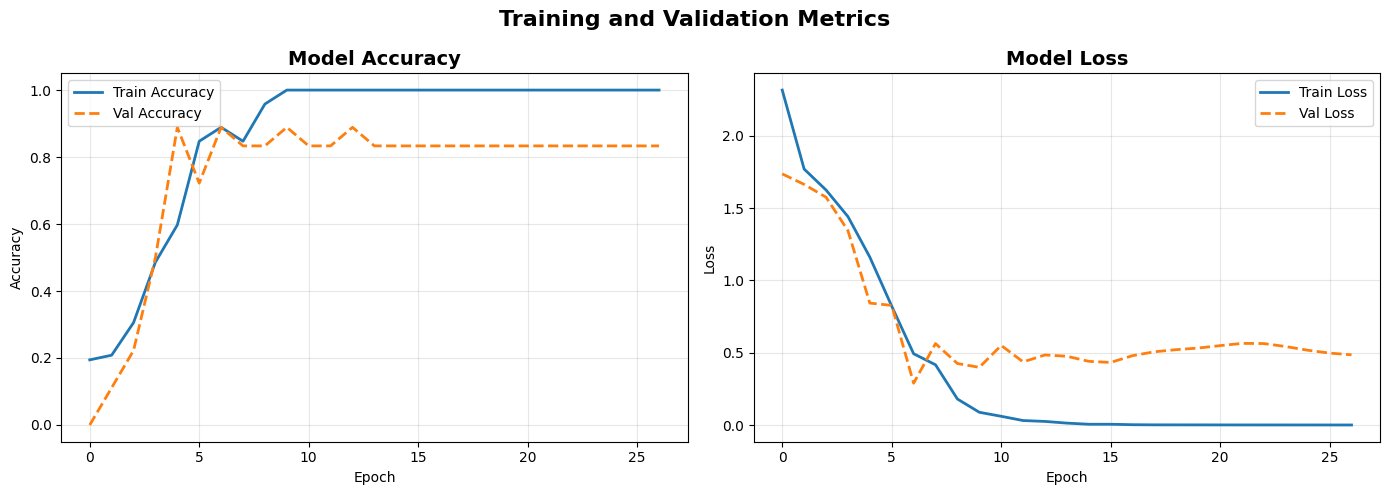

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('task4_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluate the Model

In [13]:
print("=" * 50)
print("Evaluating on TEST set")
print("=" * 50)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc * 100:.2f}%)")

Evaluating on TEST set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.4000 - loss: 1.1940

Test Loss    : 1.1940
Test Accuracy: 0.4000  (40.00%)


Save and Load the Model

In [14]:
#Save
MODEL_PATH = '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/fruit_cnn_final.h5'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load
loaded_model = keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

# Re-evaluate
print("\nRe-evaluating loaded model on TEST set:")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"Loaded Model – Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc:.4f}")

Model saved to: /content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-5/fruit_cnn_final.h5
Model loaded successfully.

Re-evaluating loaded model on TEST set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.4000 - loss: 1.1940
Loaded Model – Test Loss: 1.1940 | Test Accuracy: 0.4000


Predictions and Classification Report

In [15]:
from sklearn.metrics import classification_report

# ── Collect all true labels and predictions from the test set ────
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)

# ── Sample predictions ───────────────────────────────────────────
print("Sample Predictions (first 10 test images):")
print("-" * 45)
print(f"{'Index':<8}{'Predicted':<20}{'Actual':<20}")
print("-" * 45)
for i in range(min(10, len(y_true))):
    print(f"{i:<8}{CLASS_NAMES[y_pred[i]]:<20}{CLASS_NAMES[y_true[i]]:<20}")

print()

# ── Classification Report ────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES
)
print(report)

Sample Predictions (first 10 test images):
---------------------------------------------
Index   Predicted           Actual              
---------------------------------------------
0       cupuacu             acai                
1       cupuacu             acai                
2       acai                acai                
3       acai                acai                
4       acai                acai                
5       cupuacu             cupuacu             
6       graviola            cupuacu             
7       graviola            cupuacu             
8       cupuacu             cupuacu             
9       cupuacu             cupuacu             

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.50      0.60      0.55         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.50      0.80      0.62         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
Visualise Predictions on Sample Test Images

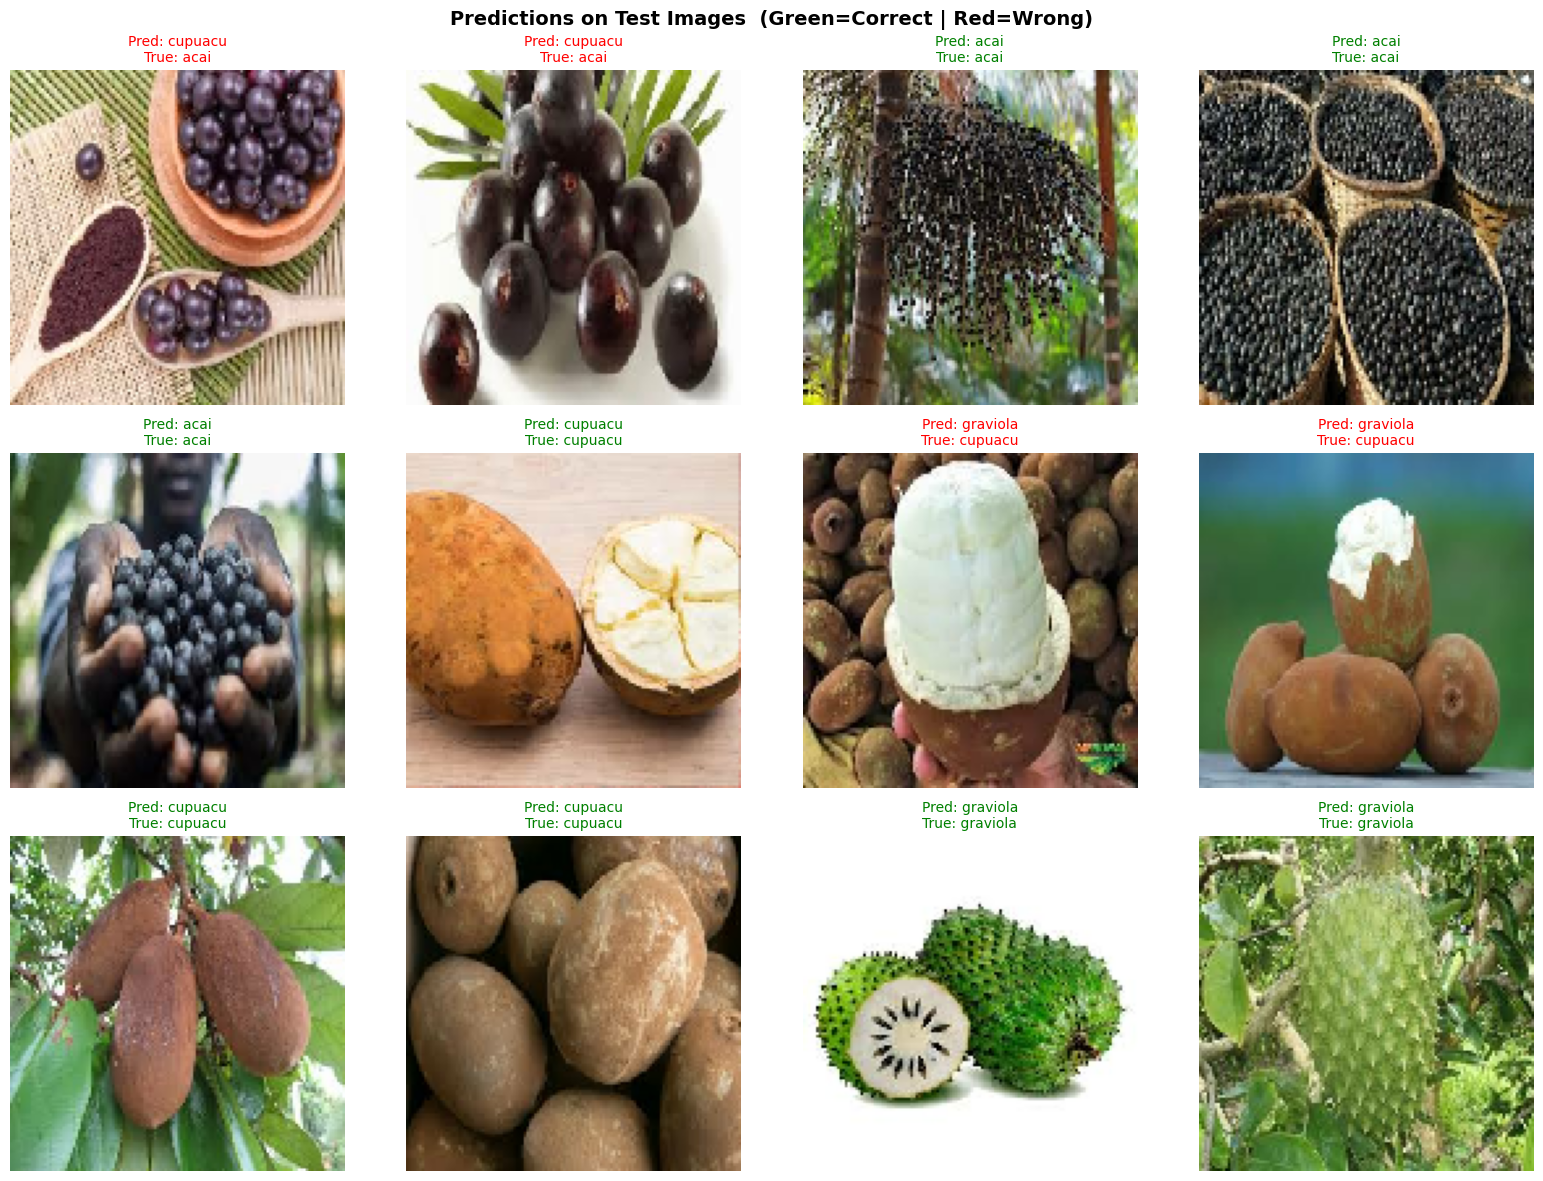

In [16]:
# Show first 12 test images with predicted vs actual labels
sample_imgs, sample_labels_batch = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_imgs, verbose=0), axis=1)

n_show = min(12, len(sample_imgs))
cols   = 4
rows   = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i in range(n_show):
    img       = sample_imgs[i].numpy()
    true_cls  = CLASS_NAMES[sample_labels_batch[i]]
    pred_cls  = CLASS_NAMES[sample_preds[i]]
    correct   = true_cls == pred_cls

    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {pred_cls}\nTrue: {true_cls}",
        color='green' if correct else 'red',
        fontsize=10
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Predictions on Test Images  (Green=Correct | Red=Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task7_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
